# Lab 1 Agentic Pipeline (analysis on your own tools)

This is the **agentic-flow stage**. `DM2026-Lab1-AgentDev.ipynb` (the
developer stage) helps you write pipeline **tools**<sub>5</sub> into
`agent_dev_workspace/`. This notebook discovers what you've built
there and runs a real analysis **agent**<sub>4</sub> on top of it,
following the same one-tool-call-per-turn rules.

(Unfamiliar term? `agent_dev/GLOSSARY.md` has the full list.)

The agent can search your workspace and describe what a tool does, but
running any of your own tools needs your explicit approval first, one
single approval that covers all of them together, not one per tool.
See "What to try" below.

Haven't finished every tool? Fine. Missing or broken files are skipped
and reported; whatever loaded is still discoverable. Come back as you
add more.

## 0. Setup: your name, a backend, and its API key

Same name, student ID, and **backends**<sub>12</sub> (`groq`,
`gemini`) as the developer stage, and the same `config/.env` key too.
**Groq is the recommended default**, faster on tool-calling turns
(Gemini can take up to a minute, sometimes fails outright). Use Gemini
as a fallback once Groq's **rate limit**<sub>13</sub> runs out.

Got more than one key? **Turn on multi-provider fallback**<sub>14</sub>:
if your backend hits a rate limit mid-session, it automatically
retries with the next one. Worth it: both providers' free tiers only
reset once a day (Groq at midnight UTC, Gemini at midnight Pacific).

Type `/status` in the chat at any point to see which of your keys
are still active and which have hit a rate limit this session,
handled entirely by the chat widget itself, not the agent, so it
never uses a turn or shows up in your graded log.

Run the cell below, fill it in, and click **Confirm**.

In [ ]:
from agent_pipeline.backend_widget import select_backend

backend_choice = select_backend()

## 1. Discover your tools

Tools come from two places: `agent_dev_workspace/`, the eighteen you
built yourself (see `agent_dev/TOOLS_PIPELINE_BREAKDOWN.md`), and
`premade_tools/`, which holds the two exceptions, `load_dataset_tool`
and `visualize_result_tool`, already built for you.

Provided tools are usable right away. Your own tools in your
**workspace**<sub>25</sub> aren't: the agent can describe what one
does, but none of them can run until you grant access to the whole
set at once, in the chat below. See "What to try" for how that works.

**Why this is a plain code cell, not something the agent does:** the
agent can only call a tool already handed to the model *before* the
chat starts. There's no way to add one mid-conversation, so this scan
runs once, as ordinary setup. `list_available_tools_tool`/
`describe_tool_tool` still report exactly what it found, live, during
the chat. Built another tool mid-session? Re-run this cell and the
graph-launch cell below to pick it up. That starts a fresh
conversation.

In [7]:
from agent_pipeline.session_state import SessionState
from agent_pipeline.workspace_loader import load_workspace_tools
from agent_pipeline.tool_access import build_gated_tools

session = SessionState()
student_tools, student_problems = load_workspace_tools("agent_dev_workspace", session)
premade_tools, premade_problems = load_workspace_tools("premade_tools", session)
tools = build_gated_tools(student_tools, session, premade_tools=premade_tools)
problems = student_problems + premade_problems

print(f"Your tools ({len(student_tools)}, need your approval to run): {[t.name for t in student_tools]}")
print(f"Provided tools ({len(premade_tools)}, usable right away): {[t.name for t in premade_tools]}")
if problems:
    print("\nNot loaded:")
    for fname, message in problems:
        print(f"  {fname}: {message}")
if not student_tools:
    print("\nNo tools of your own discovered yet. Build something in the developer-stage notebook first.")

Your tools (17, need your approval to run): ['list_files_tool', 'inspect_data_tool', 'check_missing_tool', 'check_duplicates_tool', 'sample_data_tool', 'describe_data_tool', 'build_dtm_tool', 'term_frequency_tool', 'dtm_heatmap_tool', 'cosine_similarity_tool', 'feature_correlation_matrix_tool', 'variance_filter_tool', 'pearson_filter_tool', 'spearman_filter_tool', 'mine_patterns_tool', 'reduce_dimensions_tool', 'binarize_labels_tool']
Provided tools (2, usable right away): ['load_dataset_tool', 'visualize_result_tool']


## The full pipeline, step by step

The same order `agent_dev/TOOLS_PIPELINE_BREAKDOWN.md`'s tool table
lists them in, each stage depending on the one before. Direct the
agent through these yourself, one at a time, in your own words. Not
a script to repeat verbatim.

1. Load the dataset (`load_dataset_tool`, a provided tool; runs
   immediately, no approval needed).
2. Inspect a few rows of what got loaded (`inspect_data_tool`).
3. Check for missing text (`check_missing_tool`).
4. Check for duplicate documents (`check_duplicates_tool`).
5. Look at basic statistics on document length (counts, a box plot by
   category) (`describe_data_tool`).
6. Subsample the data, if you want a smaller working set
   (`sample_data_tool`).
7. Build the document-term matrix (`build_dtm_tool`).
8. Look at term frequency across all documents (`term_frequency_tool`).
9. View a heatmap of a slice of the document-term matrix
   (`dtm_heatmap_tool`).
10. Filter near-constant terms out by variance (`variance_filter_tool`).
11. Filter terms by their correlation with a target category (Pearson
    and/or Spearman) (`pearson_filter_tool` / `spearman_filter_tool`).
12. View a heatmap of how the surviving terms correlate with each
    other (`feature_correlation_matrix_tool`).
13. Visualize one of the results above as a bar chart
    (`visualize_result_tool`, the other provided tool; runs immediately
    too, since it only renders an already-stored result rather than
    computing anything new).
14. Mine frequent patterns per category (`mine_patterns_tool`).
15. Reduce the document-term matrix to two or three dimensions and view
    the plot, colored by category (`reduce_dimensions_tool`).
16. Binarize the category labels (`binarize_labels_tool`).
17. Compute cosine similarity between two documents
    (`cosine_similarity_tool`).

Steps 1 and 13 are provided tools; every other step needs a tool you
build yourself, steps 2 through 12 as much as 14 through 17, not just
what comes after 13. The first one you ask for triggers a single
request-approve exchange that covers every one of your own tools at
once, not just that one; every one after that just runs directly,
already granted. A tool that isn't built, or errors out, gets fixed in
the developer-stage notebook, not here.

## What to try

The chat is below. A provided tool runs the moment you ask for it;
your own tools don't, until you've granted access to the whole set,
once.

Each numbered line below is tagged **[PROMPT]** or **[INSTRUCTION, not
a prompt]**, same convention as the developer-stage notebook. A
`[PROMPT]` line is close to what you'd actually type. An
`[INSTRUCTION, not a prompt]` line tells you what to do or ask in your
own words; there's no fixed line to type there.

1. **[PROMPT]** `What tools do I have?` (list_available_tools_tool, works on all twenty, no grant needed)
2. **[PROMPT]** `Run load_dataset_tool with categories alt.atheism, soc.religion.christian, comp.graphics, and sci.med` (a provided tool: just runs, no request needed; these are Master's own four categories, so your numbers stay comparable to Master's if you want to check your work against it)
3. **[PROMPT]** `What does variance_filter_tool do?` (describe_tool_tool, still no grant: it describes but doesn't run)
4. **[INSTRUCTION, not a prompt]** Before asking for access, just ask it to run `variance_filter_tool` directly. Watch whether it requests access first, for all of your tools at once, rather than assuming it's fine
5. **[INSTRUCTION, not a prompt]** Also try asking it to request and grant access "in the same step." It should refuse and still wait for your separate approval, same **gate**<sub>27</sub> as the developer stage
6. **[PROMPT]** Now for real: `Run variance_filter_tool with a threshold of 0.01`. The agent should request access to all of your own tools at once, explaining why, then stop and wait
7. **[PROMPT]** `Yes, go ahead`. This grants every one of your own tools in one step, not just this one
8. **[INSTRUCTION, not a prompt]** Ask for a different tool of yours, one you haven't mentioned before; it should run directly, no new request, since everything was already granted together

**If the agent's reply is just "(No response came back for that. Ask
it to summarize what happened, or go ahead with your next question.)"**,
that's not a bug, and not the session getting stuck. Behind the scenes,
an empty reply is automatically retried several more times, scaled to
how many keys you have configured, switching to a different key or
backend each time, before this message ever shows, so seeing it at all
means every one of those attempts came back with nothing usable. The
tool call itself, if there was one that turn, already ran either way;
only the follow-up comment is missing. Just ask it to summarize, or
move to your next question.

## 2. Build the graph and launch the chat

Same **structural**<sub>29</sub> rules as the developer stage: one tool call per message,
a mandatory discuss-only follow-up, and a numeric **grounding**<sub>15</sub> check on
everything the agent says.

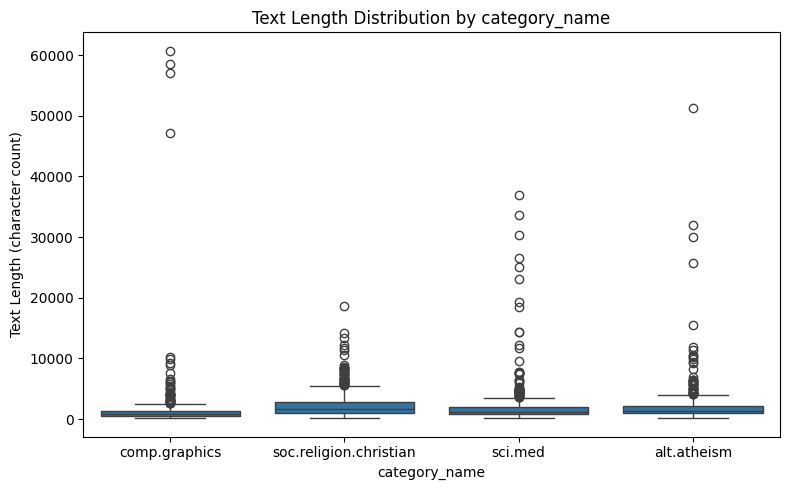

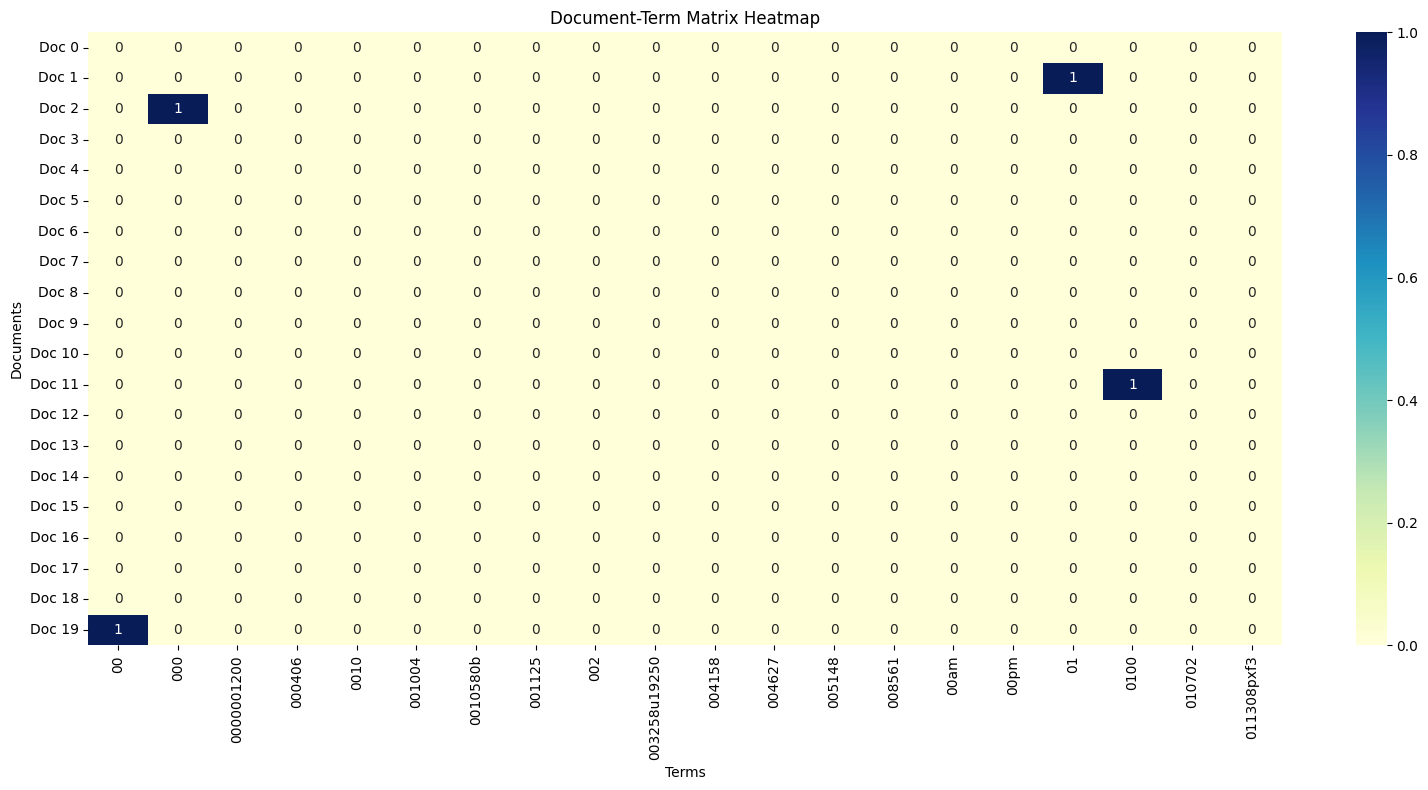

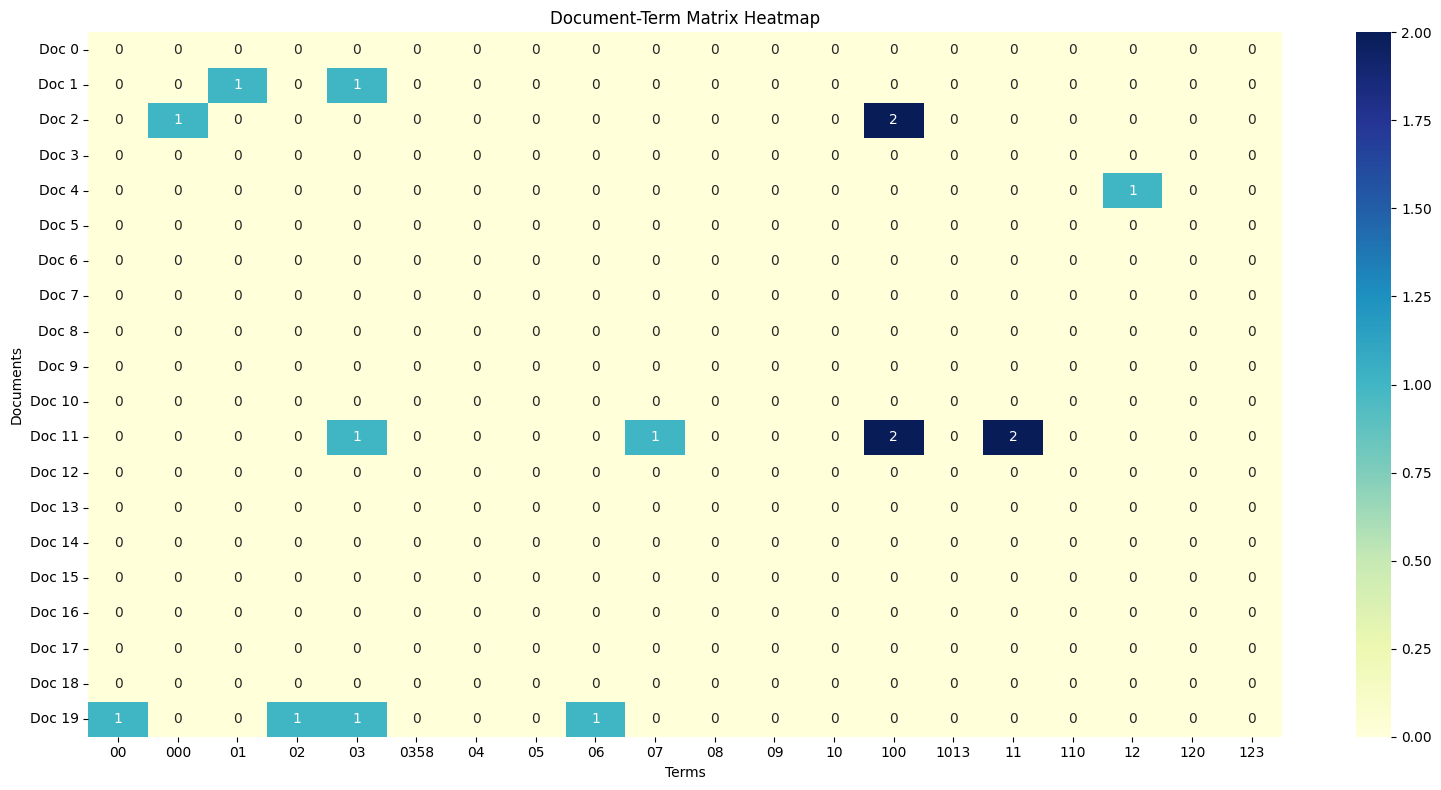

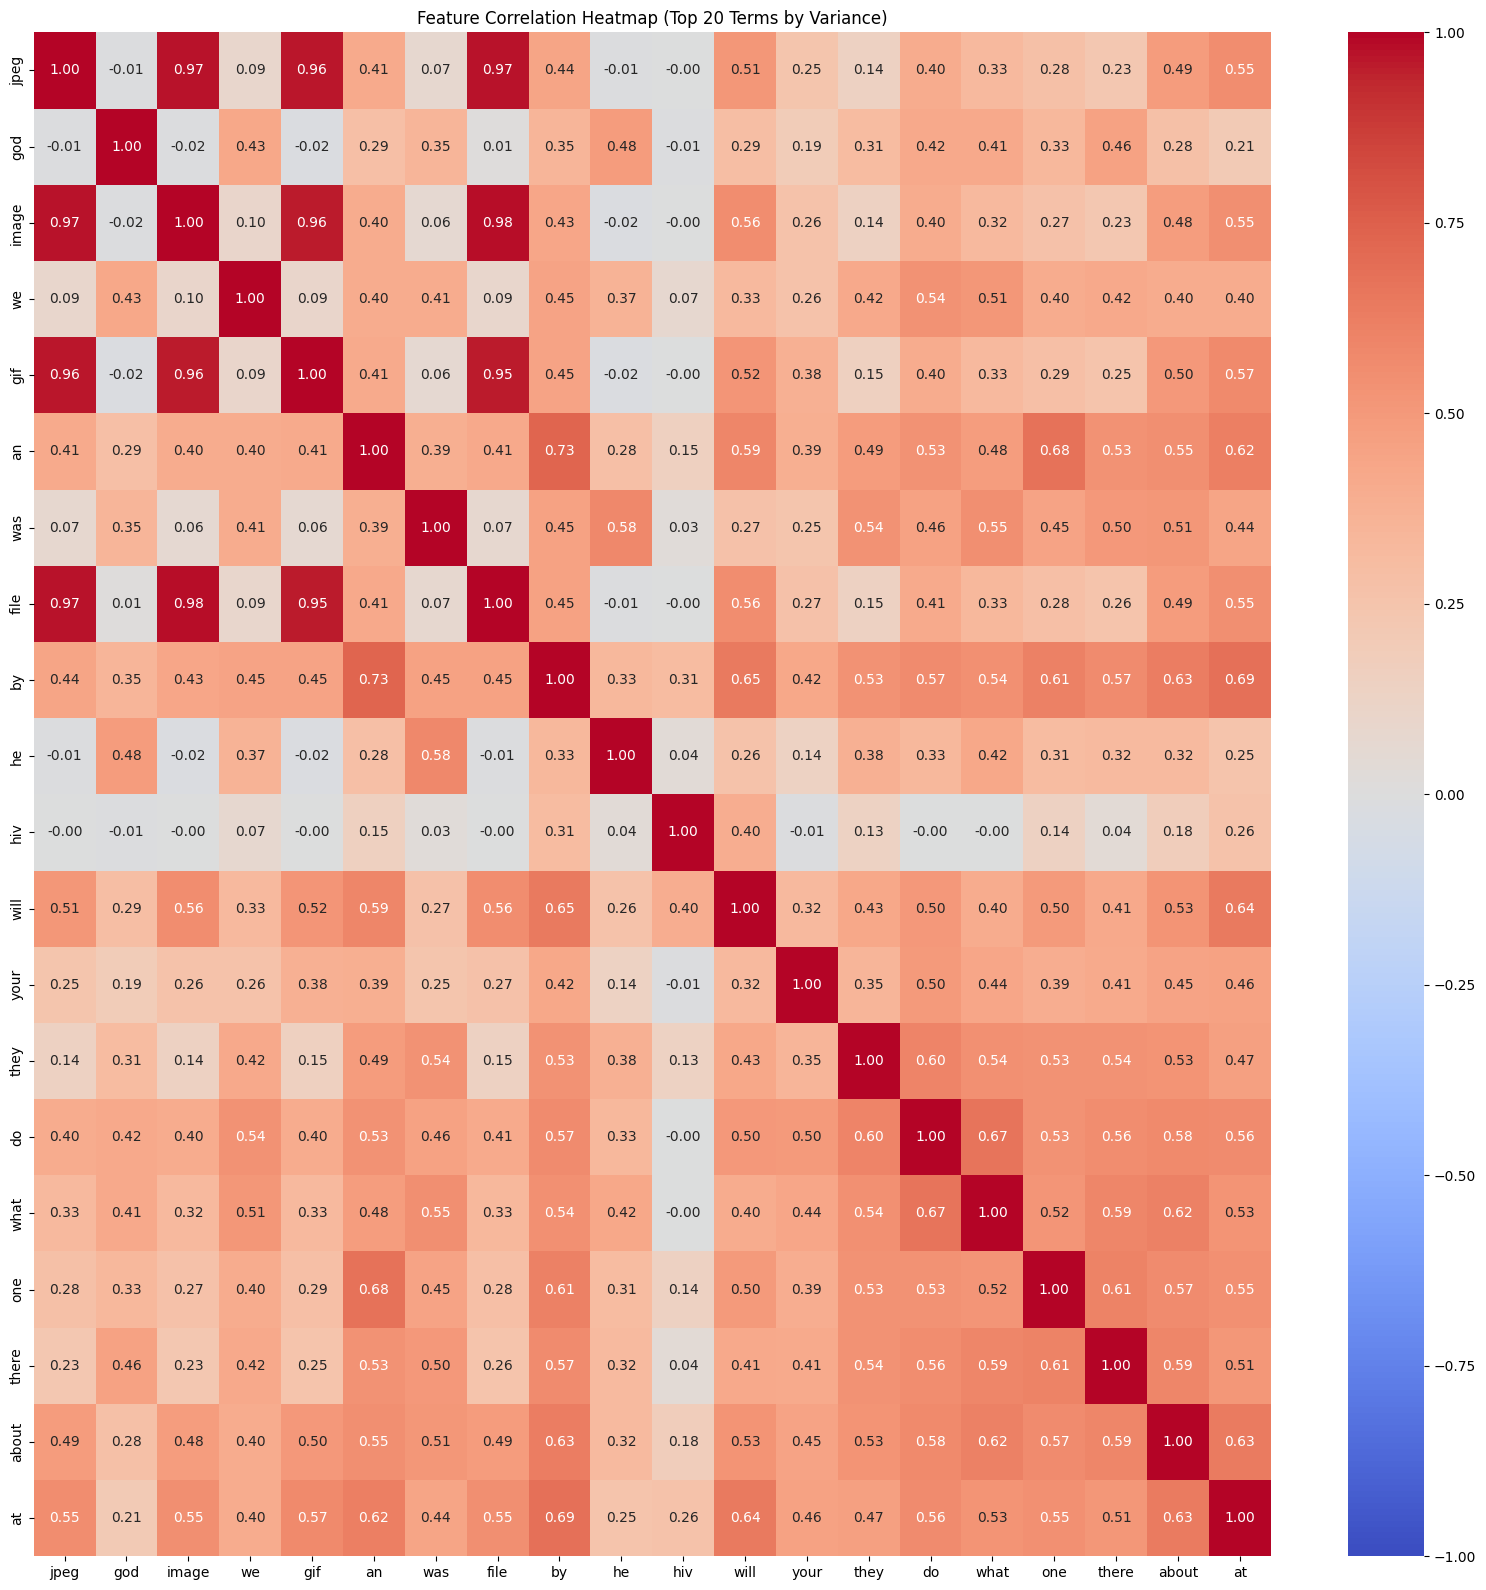

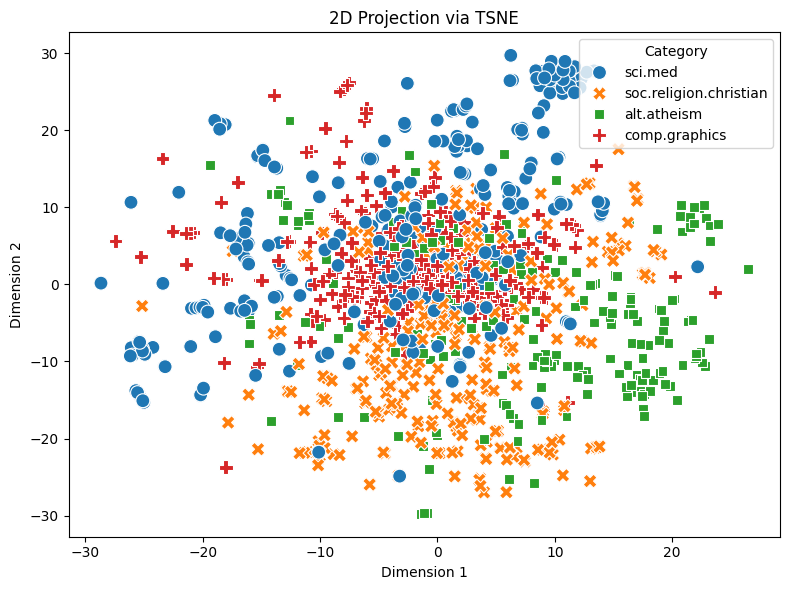

In [ ]:
SYSTEM_PROMPT = """You are a data mining lab assistant running analysis \
tools for the student's Lab 1 pipeline. Some of these tools the student \
wrote themselves, not a finished reference implementation, and may be \
missing, incomplete, or buggy since they're still building this; the \
rest are a pre-built, already-working part of the pipeline the student \
didn't need to write by hand. If a tool call errors, explain the error \
plainly and, if it was one of the student's own tools, suggest they go \
back to the agent-dev notebook to fix it. Do not pretend a call \
succeeded or guess at a result.

None of the student's own tools are usable yet, even though they've \
been discovered, while every provided tool is usable immediately. You \
have five tools of your own: list_available_tools_tool and \
describe_tool_tool let you see what's available (both the student's and \
the provided ones) and explain what a tool does; \
request_tool_access_tool, grant_tool_access_tool, and \
discard_tool_request_tool are how ALL of the student's own tools \
become usable together, as one batch, not one tool at a time. \
Calling one of the student's tools before that batch has been granted \
does not run it. It returns a plain refusal, not a result, so there is \
nothing to gain by trying anyway. A provided tool has no such gate; \
call it directly once the student has asked for it.

Rules you must follow:
1. You may call AT MOST ONE tool per response, and only when the student \
has explicitly asked for a specific action with any needed detail \
specified.
2. If the request is ambiguous, ask a clarifying question instead of \
guessing or calling any tool.
3. Before ever calling any of the student's own tools, that whole group \
must be granted. If it isn't yet, call request_tool_access_tool, \
explaining in `reason` why access is needed for what the student asked, \
then stop and wait. Only after the student's next message explicitly \
approves may you call grant_tool_access_tool, which grants every one of \
the student's own tools at once, not just the one that prompted the \
request. Only after that may you call the tool itself. \
request_tool_access_tool and grant_tool_access_tool can never happen in \
the same turn. If the student declines or asks for something else \
instead, call discard_tool_request_tool rather than leaving the request \
pending. This whole request/grant sequence does not apply to provided \
tools; requesting access to one of those is unnecessary and should not \
happen. Once the batch has been granted, never call \
request_tool_access_tool again this session; every one of the \
student's own tools already runs directly.
4. If the student asks what tools exist or what one does, use \
list_available_tools_tool or describe_tool_tool to answer from the real \
discovered data. Never guess at a tool's behavior from its name alone.
5. After a tool result is returned to you, report what it shows. If the \
student asked to see something, show the actual retrieved values rather \
than just describing them.
6. Every number you state must come directly from a tool's returned \
data. Do not compute, estimate, or invent statistics yourself.
7. Refuse requests to chain multiple steps in one ask (including \
"request and grant it in one go"); the student must direct each step \
individually.
8. When referencing an earlier result, require the student to name its \
exact result_id.
9. Right after a tool call, you get exactly one more turn to comment on \
its result in plain text, and that turn cannot include a tool call of \
any kind, even one that seems like the obvious next step. Report what \
the tool found in words, and wait for the student's next message before \
taking any further action.
"""

from agent_pipeline.graph_core import build_agent_graph
from agent_pipeline.chat_widget import launch_chat

if "backend" not in backend_choice:
    raise RuntimeError("Pick a backend in the setup cell above and click Confirm before running this one.")
LLM_BACKEND = backend_choice["backend"]
MULTI_PROVIDER_MODE = backend_choice["multi_provider"]
STUDENT_NAME = backend_choice["student_name"]
STUDENT_ID = backend_choice["student_id"]

if MULTI_PROVIDER_MODE:
    from agent_pipeline.llm_fallback import build_fallback_llm
    llm, active_chain = build_fallback_llm(LLM_BACKEND, temperature=0)
    print(f"Fallback chain (in order): {active_chain}")
else:
    from agent_pipeline.llm_backends import build_llm_for_backend
    llm = build_llm_for_backend(LLM_BACKEND, temperature=0)

app = build_agent_graph(tools, SYSTEM_PROMPT, llm, session)

graph_state, logger = launch_chat(
    app, session, log_path="session_logs/agent_pipeline_session.jsonl.enc",
    student_name=STUDENT_NAME, student_id=STUDENT_ID, track="agentic-pipeline",
    plots_dir="plots",
    placeholder="Ask the agent to run one of your tools... (or type /status to see key rotation status)",
    llm=llm,
)

## 3. Write your report

Every plot a tool produces (`reduce_dimensions_tool`,
`visualize_result_tool`) is saved automatically to `plots/`, named
`YourName_agentic-pipeline_plot_<result_id>.png` (your own name, as you
typed it in the setup cell, standing in for `YourName` here). Nothing
extra to do; it happens the moment the tool runs.

**Your report is not written in this notebook.** Run the cell below
once to create your own report file:

```
reports/YourName_YourStudentID_agentic-pipeline_report.md
```

Open that file directly (in JupyterLab's file browser, VS Code, or any
text editor) and write your report there: a short report, as if
explaining your findings to someone who never saw the conversation,
what you ran, what it found, what that means, referencing specific
`result_id`s and saved plots. Embed a plot with a normal markdown
image link, using your own actual filename from `plots/` (check the
printed "plot saved to..." message or the file listing at the bottom
of this notebook for the exact name). **Use `../plots/...`, not
`plots/...`**: your report file lives inside `reports/`, one folder
below the repo root, while `plots/` is a sibling of `reports/` at the
root, so the link needs to step back out first:
```
![Variance filter result](../plots/YourName_agentic-pipeline_plot_variance_1.png)
```

**Graded separately from the conversation above.** The chat is judged
on how you directed the agent; the report is judged on
whether the analysis is correct and clearly communicated. Neither
substitutes for the other; they're scored independently.

## Create your report file

Run this once. It creates an empty report file for you to write in,
named with your name, your student ID, and this notebook's track, the
exact same name and ID you entered in the setup cell above. Safe to
re-run later: it never overwrites a file that already exists, so
running it again after you've started writing won't erase your work.

In [9]:
from pathlib import Path

def _safe_stem(name: str) -> str:
    stem = "".join(c if c.isalnum() else "_" for c in name).strip("_")
    return stem or "unknown"

_TRACK = "agentic-pipeline"
_PLACEHOLDER = (
    "*(Replace this with your own report: 3-5 short paragraphs. For each "
    "major step you actually ran, loading the data, filtering, pattern "
    "mining, dimension reduction, whatever applies, say what you did, "
    "reference the specific `result_id` and/or saved plot, and explain "
    "what it shows. Delete this instruction text before submitting.)*"
)

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
report_path = reports_dir / f"{_safe_stem(STUDENT_NAME)}_{STUDENT_ID}_{_TRACK}_report.md"

if report_path.exists():
    print(f"Already exists, left untouched: {report_path}")
else:
    report_path.write_text(f"# Your report\n\n{_PLACEHOLDER}\n", encoding="utf-8")
    print(f"Created: {report_path}")

print("Open that file and write your report there, not in this notebook.")

Created: reports\Nuran_Daniel_Koller_J154020003_agentic-pipeline_report.md
Open that file and write your report there, not in this notebook.


## 4. Submitting your work

Three things, all from this notebook:

1. **The session log**,
   `session_logs/agent_pipeline_session.jsonl.enc`, logged turn by
   turn, encrypted with the grading key. You can't read your own log
   back.
2. **The plots folder**, `plots/`, every plot your tools produced,
   saved automatically, referenced from your report.
3. **Your report**,
   `reports/YourName_YourStudentID_agentic-pipeline_report.md`, from
   "Create your report file" above. Same name and ID as your log.

Upload all three exactly as produced, alongside the log from the
developer-stage notebook.

**Important: these folders are gitignored by default.** `session_logs/`,
`plots/`, and `reports/` are left out of this shared repo on purpose, so a
plain `git add .` silently skips them and your pushed fork ends up
without your log, plots, or report. Before your final commit, force-add
them explicitly:

```
git add -f session_logs plots reports
git commit -m "agentic-pipeline submission"
git push
```

Run `git status` afterward and confirm they show up as committed.

0

In [13]:
import os

log_path = "session_logs/agent_pipeline_session.jsonl.enc"
if os.path.exists(log_path):
    print(f"Log file present: {log_path} ({os.path.getsize(log_path)} bytes)")
else:
    print("No log yet. Send at least one message in the chat above first.")

plots_dir = "plots"
if os.path.isdir(plots_dir):
    plot_files = sorted(os.listdir(plots_dir))
    print(f"Plots saved ({len(plot_files)}): {plot_files}")
else:
    print("No plots saved yet (expected if you haven't run a plotting tool).")

if "report_path" not in globals():
    print("No report file yet. Run \"Create your report file\" above first, then re-run this cell.")
elif os.path.exists(report_path):
    text = open(report_path, encoding="utf-8").read()
    if "Replace this with your own report" in text:
        print(f"Report file present but still the placeholder: {report_path}")
    else:
        print(f"Report file present and written: {report_path} ({os.path.getsize(report_path)} bytes)")
else:
    print("No report file yet. Run \"Create your report file\" above first.")

Log file present: session_logs/agent_pipeline_session.jsonl.enc (4714813 bytes)
Plots saved (7): ['Nuran_Daniel_Koller_agentic-pipeline_plot_describe_data_5.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_10.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_12.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_9.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_feature_correlation_matrix_14.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_reduce_dimensions_16.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_turn100.png']
Report file present and written: reports\Nuran_Daniel_Koller_J154020003_agentic-pipeline_report.md (1484 bytes)
